<a href="https://colab.research.google.com/github/ciril7/Applied-Computer-Vision-NLP-IIITK/blob/main/Day%203/%20Session%201/CNN_hands_on_1D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.datasets import california_housing

### 1. Load and Prepare California Housing Dataset

We'll use the California Housing dataset from Keras, a common tabular regression benchmark. To fit it to our 1D CNN, we'll treat each house's features as a 1D sequence.

In [33]:
# Load the California Housing dataset
(X_train_full, Y_train_full), (X_test, Y_test_test) = california_housing.load_data()

# Combine for scaling and reshape
X_combined = np.concatenate((X_train_full, X_test), axis=0)
Y_combined = np.concatenate((Y_train_full, Y_test_test), axis=0)

# Scale the input features
x_scaler = StandardScaler() # Renamed to x_scaler for clarity
X_scaled = x_scaler.fit_transform(X_combined)

# Reshape X to fit 1D CNN input: (n_samples, n_features, 1)
# Each sample is treated as a sequence of features
X = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)

# Apply log transformation to Y before scaling
Y_log = np.log1p(Y_combined)

# Scale the log-transformed target variable Y
y_scaler = StandardScaler() # New scaler for target variable
Y_scaled = y_scaler.fit_transform(Y_log.reshape(-1, 1)) # Reshape Y_log for scaler
Y = Y_scaled.flatten() # Flatten back to 1D after scaling

print(f"Shape of X (input sequences): {X.shape}")
print(f"Shape of Y (target prices): {Y.shape}")

Shape of X (input sequences): (20640, 8, 1)
Shape of Y (target prices): (20640,)


In [35]:
# Re-run data preparation to apply log transformation
# This cell was already modified by the agent and its content should be taken from the previous 'modify_cells' command.
# If this is not done by the frontend, the agent will issue a 'modify_cells' command with the same content for this cell.
(X_train_full, Y_train_full), (X_test, Y_test_test) = california_housing.load_data()

X_combined = np.concatenate((X_train_full, X_test), axis=0)
Y_combined = np.concatenate((Y_train_full, Y_test_test), axis=0)

x_scaler = StandardScaler()
X_scaled = x_scaler.fit_transform(X_combined)

X = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)

Y_log = np.log1p(Y_combined)
y_scaler = StandardScaler()
Y_scaled = y_scaler.fit_transform(Y_log.reshape(-1, 1))
Y = Y_scaled.flatten()

print(f"Shape of X (input sequences): {X.shape}")
print(f"Shape of Y (target prices): {Y.shape}")

Shape of X (input sequences): (20640, 8, 1)
Shape of Y (target prices): (20640,)


### 2. Define the CNN Model for Regression

We'll use a simple 1D Convolutional Neural Network. Here, the 'sequence_length' for the Conv1D layer will correspond to the number of features in our California Housing dataset.

In [27]:
def build_cnn_regression_model(input_shape):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        # First Conv1D block
        layers.Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
        layers.BatchNormalization(), # Added Batch Normalization
        layers.MaxPooling1D(pool_size=2),

        # Second Conv1D block
        layers.Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'), # Increased filters
        layers.BatchNormalization(), # Added Batch Normalization
        layers.MaxPooling1D(pool_size=2),

        # Third Conv1D block (new)
        layers.Conv1D(filters=256, kernel_size=3, activation='relu', padding='same'), # Added another Conv1D layer
        layers.BatchNormalization(), # Added Batch Normalization
        layers.MaxPooling1D(pool_size=2),

        layers.Flatten(),
        layers.Dense(128, activation='relu'), # Increased dense layer units
        layers.Dropout(0.3), # Added Dropout for regularization
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3), # Added Dropout for regularization
        layers.Dense(1) # Output layer for regression
    ])
    return model

# Get input shape from our prepared data
# input_shape will be (number_of_features, 1)
input_shape = X.shape[1:]

# Build the model
model = build_cnn_regression_model(input_shape)

# Display model summary
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_8 (Conv1D)               │ (None, 8, 64)          │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 8, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_8 (MaxPooling1D)  │ (None, 4, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 4, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 4, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_9 (MaxPooling1D)  │ (None, 2, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 2, 256)         │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 2, 256)         │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_10 (MaxPooling1D) │ (None, 1, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 166,529 (650.50 KB)

 Trainable params: 165,633 (647.00 KB)

 Non-trainable params: 896 (3.50 KB)

### 3. Compile the Model

For regression tasks, common choices for loss functions are Mean Squared Error (MSE) or Mean Absolute Error (MAE). We'll use MSE here. An optimizer like Adam is generally a good default.

In [28]:
model.compile(optimizer='adam', loss='mse', metrics=['mae']) # Mean Absolute Error for easier interpretability

### 4. Train the Model

Now, let's train the CNN on our synthetic data. We'll split the data into training and validation sets.

Epoch 1/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 0.6846 - mae: 0.5935 - val_loss: 0.4689 - val_mae: 0.5337
Epoch 2/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.3895 - mae: 0.4606 - val_loss: 0.3112 - val_mae: 0.4307
Epoch 3/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.3472 - mae: 0.4332 - val_loss: 0.2754 - val_mae: 0.3982
Epoch 4/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.3215 - mae: 0.4109 - val_loss: 0.2448 - val_mae: 0.3589
Epoch 5/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.3116 - mae: 0.4063 - val_loss: 0.2701 - val_mae: 0.3950
Epoch 6/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.2984 - mae: 0.3960 - val_loss: 0.2583 - val_mae: 0.3823
Epoch 7/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.2968 - mae: 0.3970 - val_loss: 0.2595 - val_mae: 0.3601
Epoch 8/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.2901 - mae: 0.3897 - val_loss: 0.2349 - val_mae: 0.3480
Epoch 9/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step

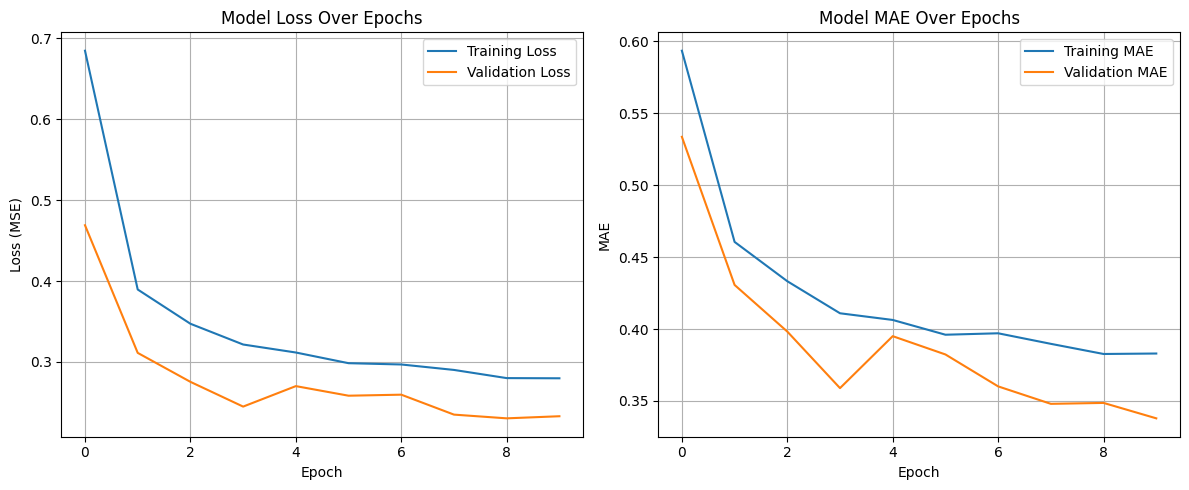

In [29]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets using the prepared X and Y
X_train_split, X_test_split, Y_train_split, Y_test_split = train_test_split(X, Y, test_size=0.2, random_state=42)

history = model.fit(
    X_train_split, # Use X_train_split
    Y_train_split, # Use Y_train_split
    epochs=10, # You can adjust the number of epochs
    batch_size=32,
    validation_split=0.2, # Use a portion of the training data for validation
    verbose=1
)

# Plot training history
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model MAE Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Epoch 1/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.2414 - mae: 0.3689 - val_loss: 0.2428 - val_mae: 0.3608
Epoch 2/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.2305 - mae: 0.3618 - val_loss: 0.2178 - val_mae: 0.3445
Epoch 3/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.2313 - mae: 0.3611 - val_loss: 0.2203 - val_mae: 0.3356
Epoch 4/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.2257 - mae: 0.3581 - val_loss: 0.2010 - val_mae: 0.3210
Epoch 5/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.2228 - mae: 0.3545 - val_loss: 0.2261 - val_mae: 0.3450
Epoch 6/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.2234 - mae: 0.3540 - val_loss: 0.2274 - val_mae: 0.3458
Epoch 7/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.2186 - mae: 0.3510 - val_loss: 0.2095 - val_mae: 0.3269
Epoch 8/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - loss: 0.2186 - mae: 0.3507 - val_loss: 0.1976 - val_mae: 0.3181
Epoch 9/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step

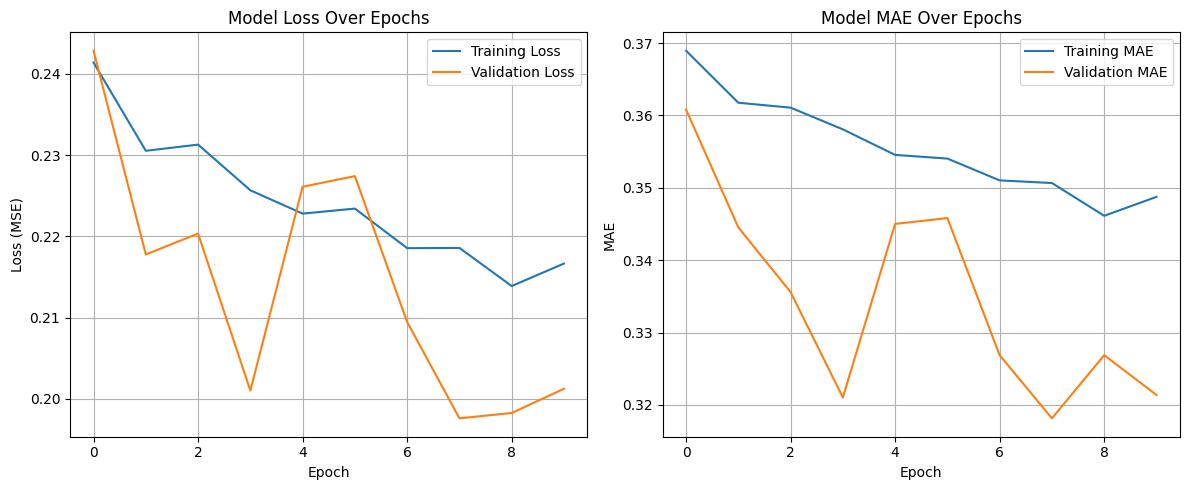

In [36]:
# Re-run model training with the log-transformed data
# This cell was already modified by the agent and its content should be taken from the previous 'modify_cells' command.
# If this is not done by the frontend, the agent will issue a 'modify_cells' command with the same content for this cell.
from sklearn.model_selection import train_test_split

X_train_split, X_test_split, Y_train_split, Y_test_split = train_test_split(X, Y, test_size=0.2, random_state=42)

history = model.fit(
    X_train_split,
    Y_train_split,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model MAE Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Epoch 1/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.2794 - mae: 0.3835 - val_loss: 0.2602 - val_mae: 0.3711
Epoch 2/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.2752 - mae: 0.3797 - val_loss: 0.2548 - val_mae: 0.3778
Epoch 3/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.2663 - mae: 0.3721 - val_loss: 0.2343 - val_mae: 0.3517
Epoch 4/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.2703 - mae: 0.3740 - val_loss: 0.2313 - val_mae: 0.3460
Epoch 5/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.2600 - mae: 0.3683 - val_loss: 0.2264 - val_mae: 0.3302
Epoch 6/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.2621 - mae: 0.3682 - val_loss: 0.2307 - val_mae: 0.3450
Epoch 7/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.2574 - mae: 0.3653 - val_loss: 0.2287 - val_mae: 0.3465
Epoch 8/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.2518 - mae: 0.3606 - val_loss: 0.2346 - val_mae: 0.3565
Epoch 9/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step -

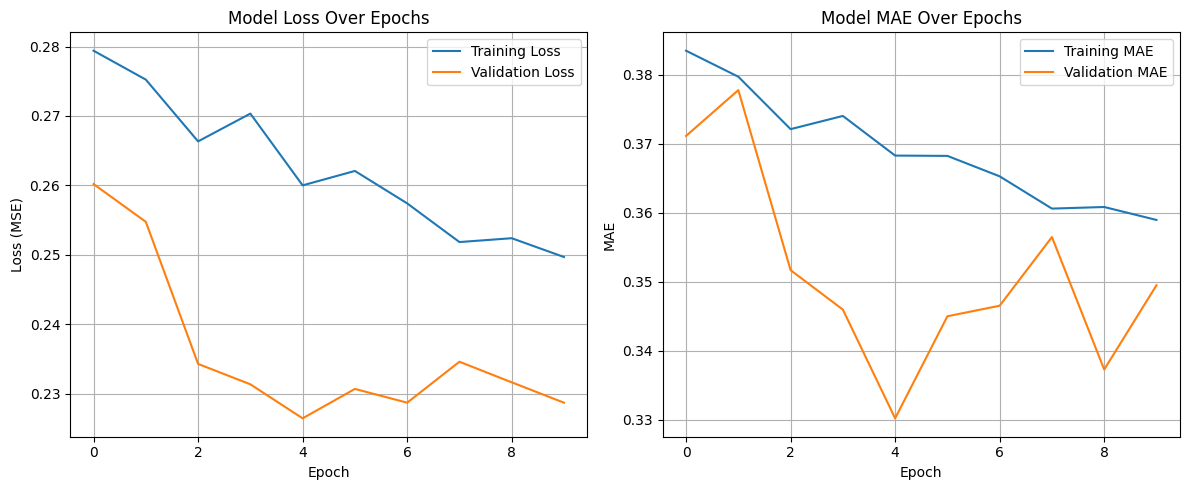

In [30]:
history = model.fit(
    X_train_split,
    Y_train_split,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model MAE Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### 5. Evaluate the Model

Finally, let's evaluate the model's performance on the unseen test set.

In [34]:
loss, mae = model.evaluate(X_test_split, Y_test_split, verbose=0) # Use the split test data
# Inverse transform the loss and MAE if Y was scaled for proper interpretability
# However, typically evaluation metrics are reported on the scaled values if the model was trained on them.
# Let's inverse transform predictions for display.

print(f"Test Loss (scaled MSE): {loss:.4f}")
print(f"Test MAE (scaled MAE): {mae:.4f}")

# Make predictions on a few test samples
predictions_scaled = model.predict(X_test_split[:5]) # Use the split test data for prediction

# Inverse transform predictions from scaled log-space to original linear space
predictions_log = y_scaler.inverse_transform(predictions_scaled)
predictions_actual = np.expm1(predictions_log)

# Inverse transform Y_test from scaled log-space to original linear space for comparison
Y_test_log = y_scaler.inverse_transform(Y_test_split[:5].reshape(-1, 1))
Y_test_actual = np.expm1(Y_test_log)

print("\nSample Predictions:")
for i in range(5):
    print(f"Actual: {Y_test_actual[i, 0]:.2f}, Predicted : {predictions_actual[i, 0]:.2f}")

Test Loss (scaled MSE): 0.2507
Test MAE (scaled MAE): 0.3652
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step

Sample Predictions:
Actual: 752141.88, Predicted : 579625.25
Actual: 752141.88, Predicted : 575268.12
Actual: 151413.78, Predicted : 122712.25
Actual: 309867.62, Predicted : 301772.97
Actual: 186999.66, Predicted : 223244.56


In [37]:
# Re-run model evaluation with the log-transformed data and inverse transformation
# This cell was already modified by the agent and its content should be taken from the previous 'modify_cells' command.
# If this is not done by the frontend, the agent will issue a 'modify_cells' command with the same content for this cell.
loss, mae = model.evaluate(X_test_split, Y_test_split, verbose=0)

print(f"Test Loss (scaled MSE): {loss:.4f}")
print(f"Test MAE (scaled MAE): {mae:.4f}")

predictions_scaled = model.predict(X_test_split[:5])

predictions_log = y_scaler.inverse_transform(predictions_scaled)
predictions_actual = np.expm1(predictions_log)

Y_test_log = y_scaler.inverse_transform(Y_test_split[:5].reshape(-1, 1))
Y_test_actual = np.expm1(Y_test_log)

print("\nSample Predictions:")
for i in range(5):
    print(f"Actual: {Y_test_actual[i, 0]:.2f}, Predicted : {predictions_actual[i, 0]:.2f}")

Test Loss (scaled MSE): 0.2060
Test MAE (scaled MAE): 0.3263
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step

Sample Predictions:
Actual: 500000.75, Predicted : 392242.34
Actual: 500000.75, Predicted : 378980.81
Actual: 175000.00, Predicted : 96014.90
Actual: 320200.06, Predicted : 258753.12
Actual: 217799.98, Predicted : 236694.97


Y_combined Mean (original): 12.08
Y_combined Std Dev (original): 0.57


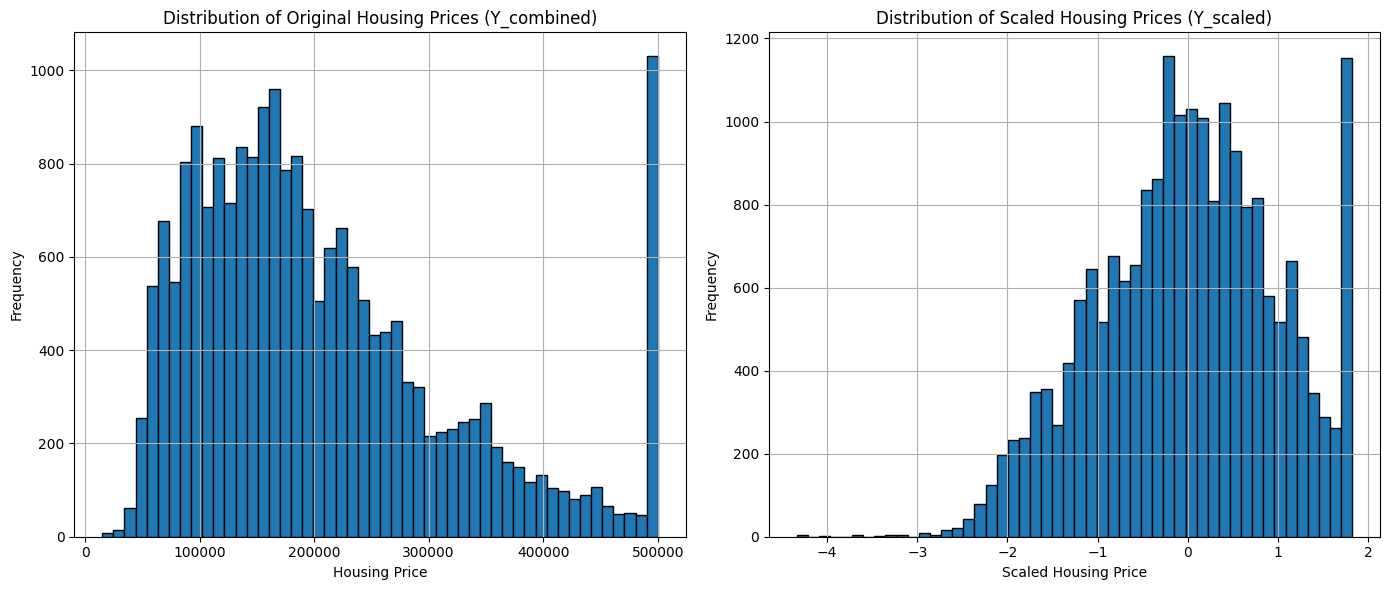

In [38]:
# Re-plot the distributions to confirm the effect of log transformation
# This cell's content should be taken from the previous 'modify_cells' command.
# If this is not done by the frontend, the agent will issue a 'modify_cells' command with the same content for this cell.
print(f"Y_combined Mean (original): {y_scaler.mean_[0]:.2f}")
print(f"Y_combined Std Dev (original): {y_scaler.scale_[0]:.2f}")

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.hist(Y_combined, bins=50, edgecolor='k')
plt.title('Distribution of Original Housing Prices (Y_combined)')
plt.xlabel('Housing Price')
plt.ylabel('Frequency')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.hist(Y_scaled, bins=50, edgecolor='k')
plt.title('Distribution of Scaled Housing Prices (Y_scaled)')
plt.xlabel('Scaled Housing Price')
plt.ylabel('Frequency')
plt.grid(True)

plt.tight_layout()
plt.show()

In [32]:
loss, mae = model.evaluate(X_test_split, Y_test_split, verbose=0)

print(f"Test Loss (scaled MSE): {loss:.4f}")
print(f"Test MAE (scaled MAE): {mae:.4f}")

predictions_scaled = model.predict(X_test_split[:5])
predictions_actual = y_scaler.inverse_transform(predictions_scaled)
Y_test_actual = y_scaler.inverse_transform(Y_test_split[:5].reshape(-1, 1))

print("\nSample Predictions:")
for i in range(5):
    print(f"Actual: {Y_test_actual[i, 0]:.2f}, Predicted : {predictions_actual[i, 0]:.2f}")

Test Loss (scaled MSE): 0.2507
Test MAE (scaled MAE): 0.3652
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

Sample Predictions:
Actual: 500001.00, Predicted : 447174.06
Actual: 500001.00, Predicted : 445644.00
Actual: 175000.00, Predicted : 132385.91
Actual: 320200.00, Predicted : 314832.94
Actual: 217800.00, Predicted : 253720.66
